In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)

In [6]:
import os
import argparse
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)


def load_data(client_path: str, record_path: str) -> pd.DataFrame:
    client = pd.read_csv(client_path)
    record = pd.read_csv(record_path)
    data = client.merge(record, on='Customer_ID', how='inner', suffixes=('_client', '_record'))
    return client, record, data


def print_overview(df: pd.DataFrame, name: str) -> None:
    print(f"=== {name} Overview ===")
    print(f"Shape: {df.shape}")
    print(df.dtypes.value_counts())
    print(df.head(5).to_string(index=False))
    print(df.describe(include='all').transpose())
    print('\n')


def missing_value_report(df: pd.DataFrame, name: str) -> None:
    print(f"=== {name} Missing Value Report ===")
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if missing.empty:
        print('No missing values found.')
    else:
        pct = 100 * missing / len(df)
        report = pd.concat([missing, pct], axis=1)
        report.columns = ['missing_count', 'missing_percent']
        print(report)
    print('\n')


def categorical_summary(df: pd.DataFrame, cat_cols: list, max_categories: int = 10) -> None:
    for col in cat_cols:
        if col not in df.columns:
            continue
        counts = df[col].value_counts(dropna=False)
        print(f"--- {col} ({len(counts)} categories) ---")
        print(counts.head(max_categories).to_string())
        if len(counts) > max_categories:
            print(f"... plus {len(counts) - max_categories} more categories")
        print('\n')


def plot_histograms(df: pd.DataFrame, numeric_cols: list, output_dir: str) -> None:
    os.makedirs(output_dir, exist_ok=True)
    for i in range(0, len(numeric_cols), 12):
        chunk = numeric_cols[i:i + 12]
        fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 18))
        axes = axes.flatten()
        for ax, col in zip(axes, chunk):
            sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30)
            ax.set_title(col)
        for ax in axes[len(chunk):]:
            ax.axis('off')
        fig.tight_layout()
        file_path = os.path.join(output_dir, f'histograms_{i // 12 + 1}.png')
        fig.savefig(file_path)
        plt.close(fig)
        print(f'Saved {file_path}')


def plot_correlation_matrix(df: pd.DataFrame, numeric_cols: list, output_dir: str) -> None:
    os.makedirs(output_dir, exist_ok=True)
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(18, 16))
    sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
    ax.set_title('Correlation Matrix')
    file_path = os.path.join(output_dir, 'correlation_matrix.png')
    fig.tight_layout()
    fig.savefig(file_path)
    plt.close(fig)
    print(f'Saved {file_path}')
    return corr


def churn_analysis(df: pd.DataFrame, cat_cols: list, numeric_cols: list, output_dir: str) -> None:
    os.makedirs(output_dir, exist_ok=True)
    if 'churn' not in df.columns:
        print('No churn column found; skipping churn analysis.')
        return

    print('=== Churn Distribution ===')
    print(df['churn'].value_counts(dropna=False))
    print(df['churn'].value_counts(normalize=True) * 100)
    print('\n')

    if df['churn'].dtype != 'int64' and df['churn'].dtype != 'float64':
        try:
            df['churn'] = df['churn'].astype(int)
        except ValueError:
            print('Churn column is not numeric and cannot be converted to int.')

    churn_rate = df['churn'].mean()
    print(f'Overall churn rate: {churn_rate:.4f}')

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.countplot(x='churn', data=df, palette='Set2', ax=ax)
    ax.set_title('Churn Count')
    ax.set_xlabel('Churn')
    file_path = os.path.join(output_dir, 'churn_count.png')
    fig.tight_layout()
    fig.savefig(file_path)
    plt.close(fig)
    print(f'Saved {file_path}')

    print('=== Churn rate by categorical variables ===')
    for col in cat_cols:
        if col not in df.columns:
            continue
        if df[col].nunique(dropna=False) > 20:
            continue
        churn_by_cat = df.groupby(col)['churn'].mean().sort_values(ascending=False)
        print(f'-- {col} --')
        print(churn_by_cat.to_string())
        print('\n')

    print('=== Top features correlated with churn ===')
    if 'churn' in df.columns:
        corr = df[numeric_cols + ['churn']].corr()['churn'].abs().sort_values(ascending=False)
        corr = corr.drop('churn')
        print(corr.head(20).to_string())
        print('\n')

    top_numeric = corr.head(6).index.tolist()
    if top_numeric:
        fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
        axes = axes.flatten()
        for ax, col in zip(axes, top_numeric):
            sns.boxplot(x='churn', y=col, data=df, ax=ax)
            ax.set_title(f'{col} by Churn')
        for ax in axes[len(top_numeric):]:
            ax.axis('off')
        file_path = os.path.join(output_dir, 'churn_boxplots.png')
        fig.tight_layout()
        fig.savefig(file_path)
        plt.close(fig)
        print(f'Saved {file_path}')


def analyze_area_and_demographics(df: pd.DataFrame, output_dir: str) -> None:
    cats = ['area', 'crclscod', 'prizm_social_one', 'income', 'ethnic']
    os.makedirs(output_dir, exist_ok=True)
    for col in cats:
        if col not in df.columns:
            continue
        if df[col].nunique(dropna=False) > 25:
            continue
        top = df[col].value_counts().nlargest(10).index
        summary = df[df[col].isin(top)].groupby(col)['churn'].mean().sort_values(ascending=False)
        print(f'Churn by top categories in {col}:')
        print(summary.to_string())
        print('\n')

        fig, ax = plt.subplots(figsize=(12, 6))
        summary.plot(kind='bar', ax=ax, color='skyblue')
        ax.set_ylabel('Churn Rate')
        ax.set_title(f'Churn Rate by {col}')
        file_path = os.path.join(output_dir, f'churn_rate_by_{col}.png')
        fig.tight_layout()
        fig.savefig(file_path)
        plt.close(fig)
        print(f'Saved {file_path}')


def run_eda(client_path: str, record_path: str, output_dir: str) -> None:
    client, record, data = load_data(client_path, record_path)

    print_overview(client, 'Client Data')
    print_overview(record, 'Record Data')
    print_overview(data, 'Merged Telecom Data')

    missing_value_report(client, 'Client Data')
    missing_value_report(record, 'Record Data')
    missing_value_report(data, 'Merged Data')

    categorical_cols = [
        'new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband',
        'refurb_new', 'phones', 'models', 'hnd_webcap', 'truck', 'rv', 'ownrent',
        'lor', 'dwlltype', 'marital', 'adults', 'infobase', 'income', 'numbcars',
        'HHstatin', 'dwllsize', 'forgntvl', 'ethnic', 'creditcd'
    ]

    numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
    if 'Customer_ID' in numeric_cols:
        numeric_cols.remove('Customer_ID')
    if 'churn' in numeric_cols and data['churn'].nunique() == 2:
        numeric_cols.remove('churn')

    categorical_summary(data, categorical_cols)
    plot_histograms(data, numeric_cols, output_dir)
    corr = plot_correlation_matrix(data, numeric_cols + (['churn'] if 'churn' in data.columns else []), output_dir)
    churn_analysis(data, categorical_cols, numeric_cols, output_dir)
    analyze_area_and_demographics(data, output_dir)

    summary_file = os.path.join(output_dir, 'telecom_eda_summary.csv')
    data.describe(include='all').transpose().to_csv(summary_file)
    print(f'Saved summary CSV: {summary_file}')


if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Complete telecom dataset EDA script.')
    parser.add_argument('--client', default='telecom/Client.csv', help='Path to Client.csv')
    parser.add_argument('--record', default='telecom/Record.csv', help='Path to Record.csv')
    parser.add_argument('--output', default='eda_plots', help='Directory for plots and summary files')
    args, _ = parser.parse_known_args()
    run_eda(args.client, args.record, args.output)


=== Client Data Overview ===
Shape: (100000, 50)
str        21
float64    21
int64       8
Name: count, dtype: int64
 uniqsubs  actvsubs new_cell crclscod asl_flag  totcalls      totmou  totrev  adjrev   adjmou  adjqty  avgrev  avgmou  avgqty  avg3mou  avg3qty  avg3rev  avg6mou  avg6qty  avg6rev prizm_social_one                          area dualband refurb_new  hnd_price  phones  models hnd_webcap  truck  rv ownrent  lor dwlltype marital  adults infobase  income  numbcars HHstatin dwllsize  forgntvl ethnic kid0_2 kid3_5 kid6_10 kid11_15 kid16_17 creditcd  eqpdays  Customer_ID
        2         1        U        A        N      1652  4228.00000 1504.62 1453.44  4085.00    1602   29.66   83.37   32.69      272      116       30    322.0    136.0     38.0                S NORTHWEST/ROCKY MOUNTAIN AREA        Y          N  149.98999     2.0     2.0       WCMB    0.0 0.0       O 15.0        S       S     1.0        M     4.0       3.0        C        A       0.0      N      U      U       

C:\Users\TM-ASUS\AppData\Local\Temp\ipykernel_5004\668455656.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='Set2', ax=ax)


-- new_cell --
new_cell
U    0.496951
N    0.496627
Y    0.490285


-- asl_flag --
asl_flag
N    0.509598
Y    0.409300


-- prizm_social_one --
prizm_social_one
R    0.527068
T    0.508373
C    0.490774
S    0.490762
U    0.484818


-- area --
area
NORTHWEST/ROCKY MOUNTAIN AREA    0.569085
SOUTH FLORIDA AREA               0.533613
CALIFORNIA NORTH AREA            0.521055
NORTH FLORIDA AREA               0.520000
NEW ENGLAND AREA                 0.517425
SOUTHWEST AREA                   0.510102
PHILADELPHIA AREA                0.506541
NEW YORK CITY AREA               0.500270
LOS ANGELES AREA                 0.498192
CHICAGO AREA                     0.495234
ATLANTIC SOUTH AREA              0.489726
DALLAS AREA                      0.487468
CENTRAL/SOUTH TEXAS AREA         0.478483
GREAT LAKES AREA                 0.476447
HOUSTON AREA                     0.475006
TENNESSEE AREA                   0.471319
OHIO AREA                        0.463755
DC/MARYLAND/VIRGINIA AREA        0.4

In [7]:
client = pd.read_csv(r"C:\Users\TM-ASUS\Documents\GitHub\gci_spring_company\telecom\Client.csv")
record = pd.read_csv(r"C:\Users\TM-ASUS\Documents\GitHub\gci_spring_company\telecom\Record.csv")

print("Client Shape:", client.shape)
print("Record Shape:", record.shape)

df = record.merge(client, on="Customer_ID", how="inner")

print("Merged Shape:", df.shape)

df.head()

Client Shape: (100000, 50)
Record Shape: (100000, 51)
Merged Shape: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


In [8]:
print(df.info())

print("\n====================")
print("DATA TYPES")
print("====================")
print(df.dtypes.value_counts())

print("\n====================")
print("DESCRIPTIVE STATS")
print("====================")
print(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     100000 non-nu

In [9]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100,2)
})

missing = missing.sort_values('Missing %', ascending=False)

missing.head(20)

,Missing Count,Missing %
numbcars,49366,49.37
dwllsize,38308,38.31
HHstatin,37923,37.92
ownrent,33706,33.71
dwlltype,31909,31.91
lor,30190,30.19
income,25436,25.44
adults,23019,23.02
infobase,22079,22.08
hnd_webcap,10189,10.19


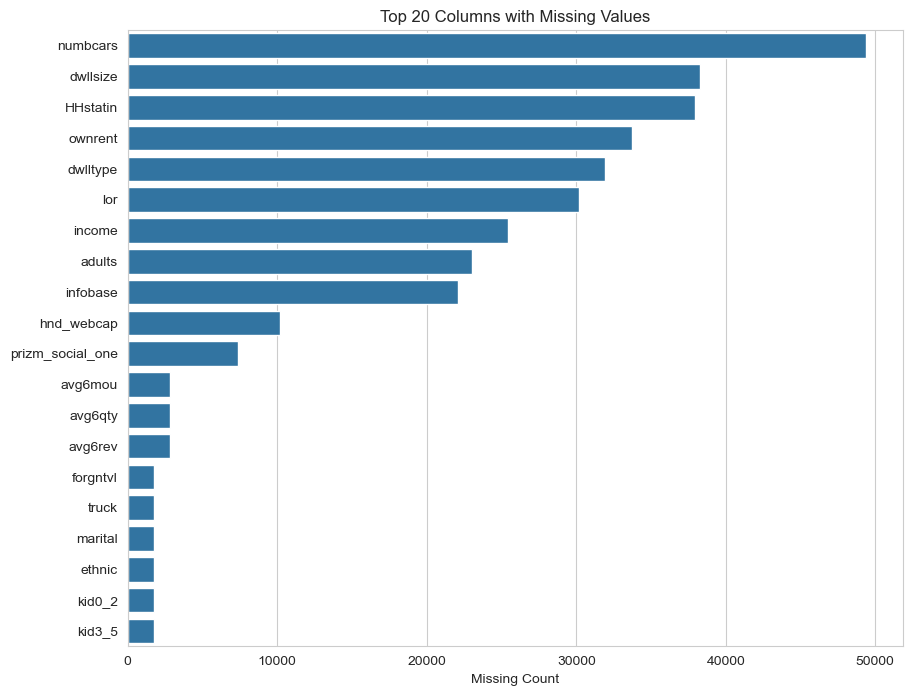

In [10]:
top_missing = missing.head(20)

plt.figure(figsize=(10,8))
sns.barplot(
    x=top_missing['Missing Count'],
    y=top_missing.index
)

plt.title("Top 20 Columns with Missing Values")
plt.xlabel("Missing Count")
plt.ylabel("")
plt.show()

In [11]:
print(df['churn'].value_counts())

print("\n")

print(df['churn'].value_counts(normalize=True)*100)

churn
0    50438
1    49562
Name: count, dtype: int64


churn
0    50.438
1    49.562
Name: proportion, dtype: float64


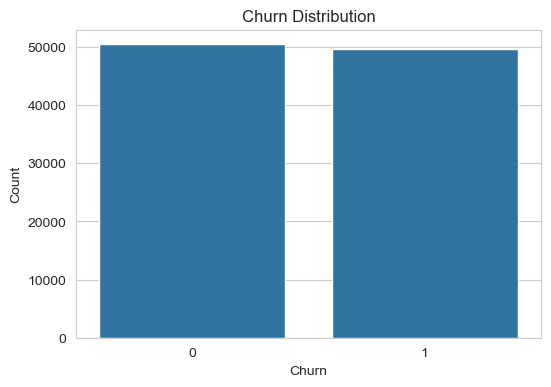

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='churn',
    data=df
)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

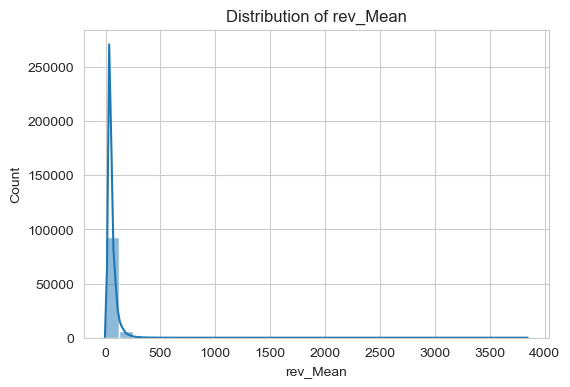

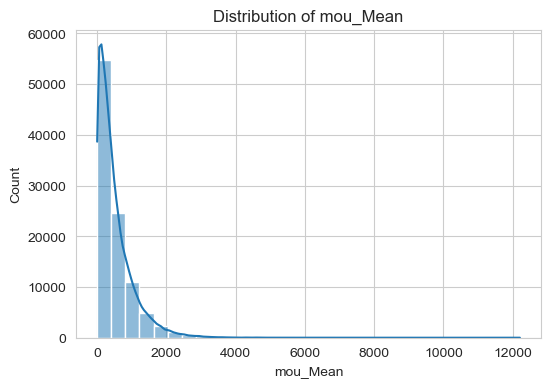

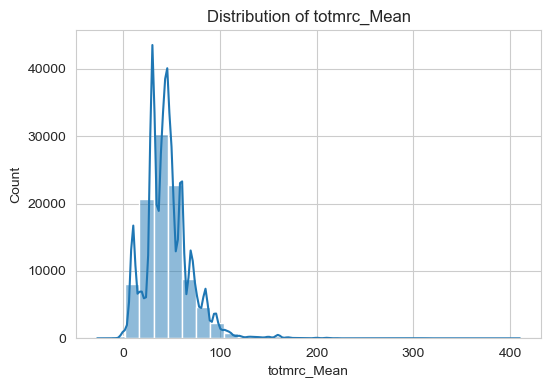

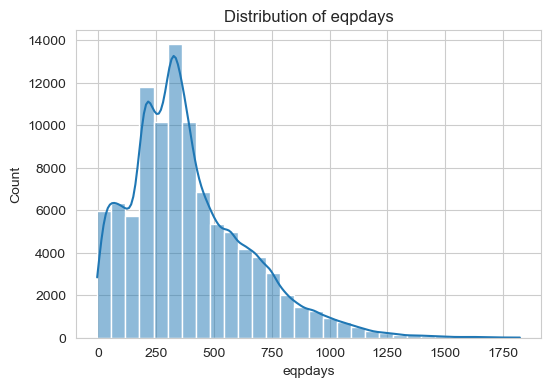

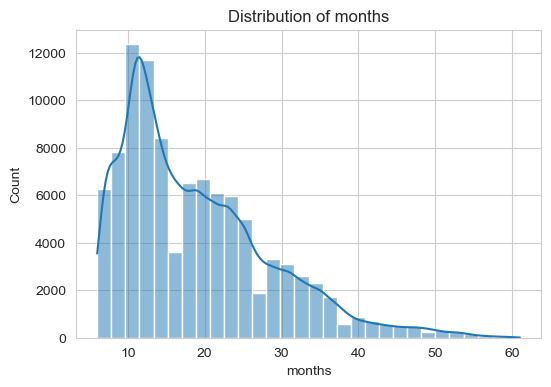

In [14]:
numerical_features = [
    'rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays',
    'months'
]

for col in numerical_features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f'Distribution of {col}')
    plt.show()

In [15]:
stayed = df[df['churn']==0]['eqpdays']
churned = df[df['churn']==1]['eqpdays']

print("Stayed Mean:", stayed.mean())
print("Churned Mean:", churned.mean())

Stayed Mean: 363.280924717965
Churned Mean: 421.08952423227475


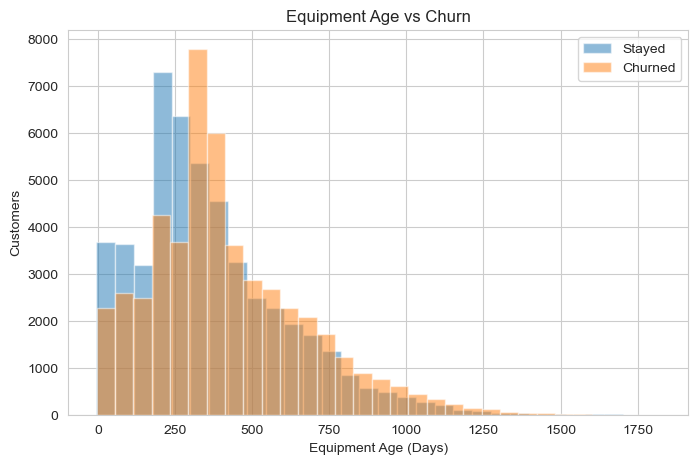

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    stayed,
    bins=30,
    alpha=0.5,
    label='Stayed'
)

plt.hist(
    churned,
    bins=30,
    alpha=0.5,
    label='Churned'
)

plt.legend()
plt.title("Equipment Age vs Churn")
plt.xlabel("Equipment Age (Days)")
plt.ylabel("Customers")

plt.show()

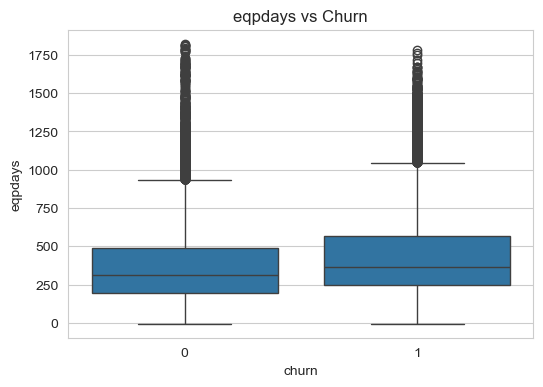

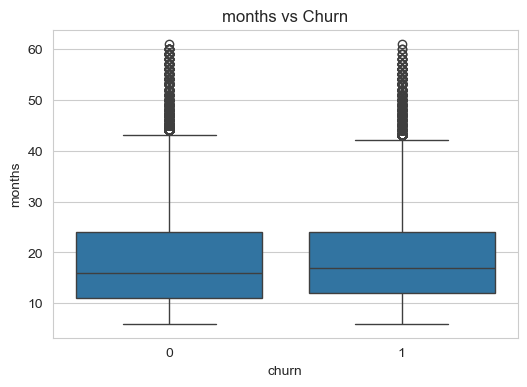

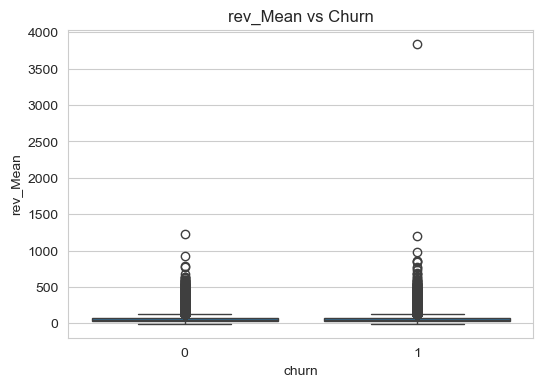

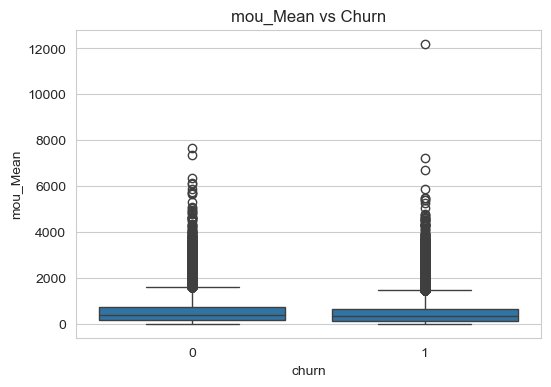

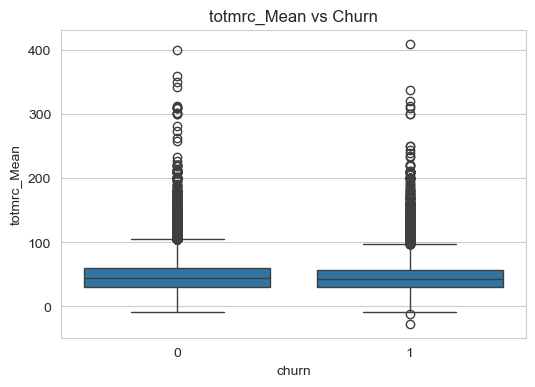

In [18]:
important_features = [
    'eqpdays',
    'months',
    'rev_Mean',
    'mou_Mean',
    'totmrc_Mean'
]

for col in important_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x='churn',
        y=col,
        data=df
    )

    plt.title(f'{col} vs Churn')

    plt.show()

In [20]:
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

corr_churn = corr_matrix['churn']

corr_churn = corr_churn.sort_values(
    ascending=False
)

print(corr_churn.head(20))
print(corr_churn.tail(20))

churn            1.000000
eqpdays          0.112691
uniqsubs         0.039882
vceovr_Mean      0.024240
ovrrev_Mean      0.023736
months           0.020991
ovrmou_Mean      0.019720
actvsubs         0.019686
roam_Mean        0.009324
change_rev       0.007832
income           0.005260
numbcars         0.002392
rv               0.000489
recv_sms_Mean   -0.000812
datovr_Mean     -0.001290
callfwdv_Mean   -0.002248
adjrev          -0.002900
totrev          -0.003017
blck_dat_Mean   -0.004016
truck           -0.004097
Name: churn, dtype: float64
owylis_vce_Mean   -0.042065
Customer_ID       -0.042764
avg3qty           -0.043883
avg6mou           -0.044060
lor               -0.044713
models            -0.045065
mou_rvce_Mean     -0.047148
mou_peav_Mean     -0.047287
opk_vce_Mean      -0.047873
peak_vce_Mean     -0.048320
plcd_vce_Mean     -0.048321
attempt_Mean      -0.048533
mou_opkv_Mean     -0.048896
avg3mou           -0.049546
comp_vce_Mean     -0.051574
complete_Mean     -0.051740
mou_

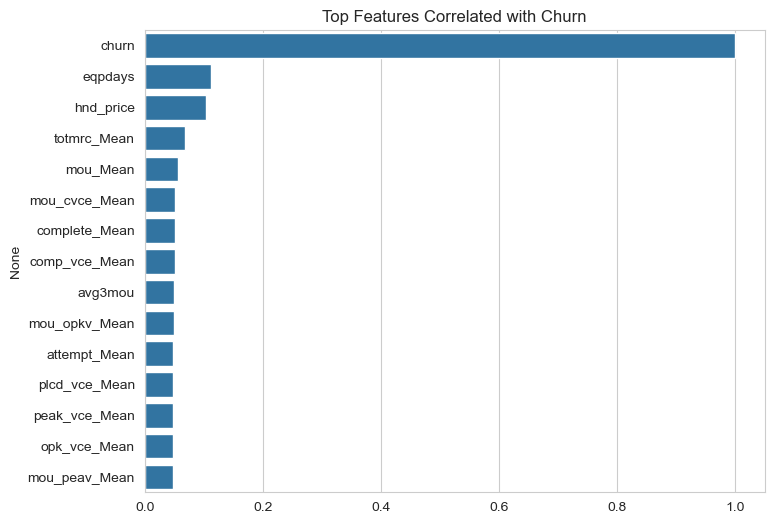

In [21]:
top_corr = corr_churn.abs().sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with Churn")

plt.show()

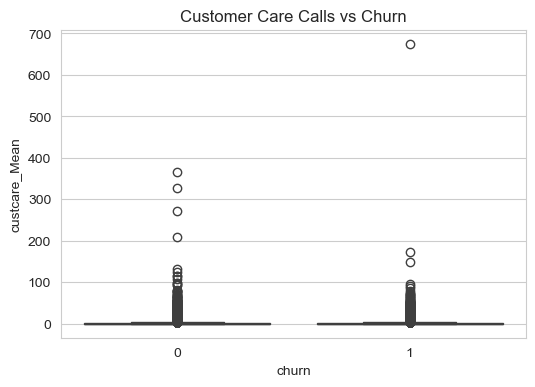

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='churn',
    y='custcare_Mean',
    data=df
)

plt.title("Customer Care Calls vs Churn")

plt.show()

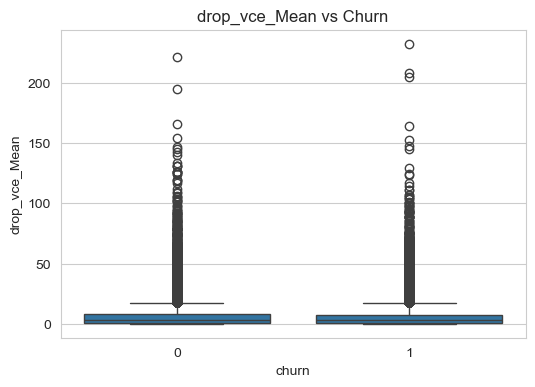

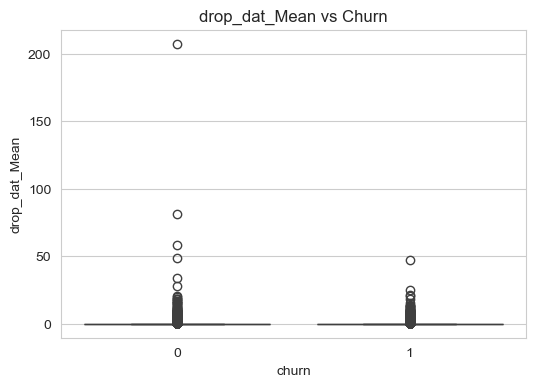

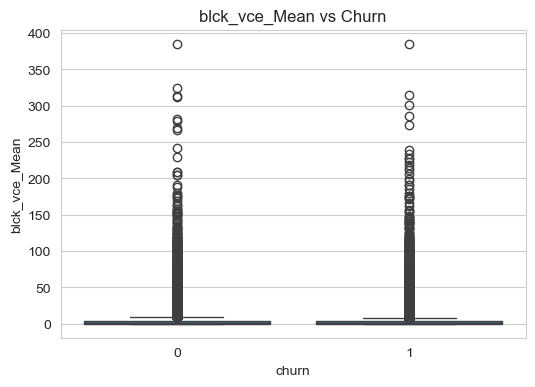

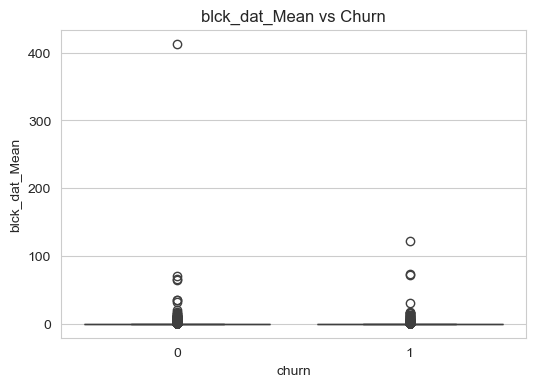

In [23]:
network_features = [
    'drop_vce_Mean',
    'drop_dat_Mean',
    'blck_vce_Mean',
    'blck_dat_Mean'
]

for col in network_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x='churn',
        y=col,
        data=df
    )

    plt.title(f'{col} vs Churn')

    plt.show()

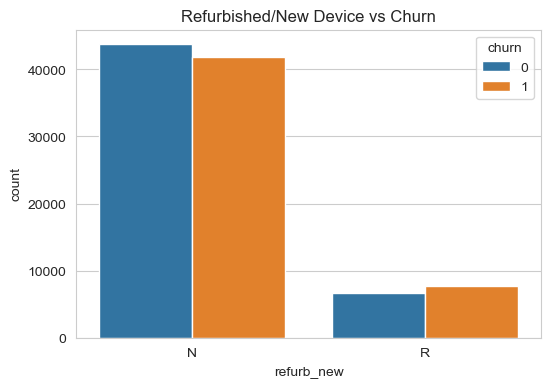

In [24]:
pd.crosstab(
    df['refurb_new'],
    df['churn'],
    normalize='index'
)*100


plt.figure(figsize=(6,4))

sns.countplot(
    x='refurb_new',
    hue='churn',
    data=df
)

plt.title("Refurbished/New Device vs Churn")

plt.show()

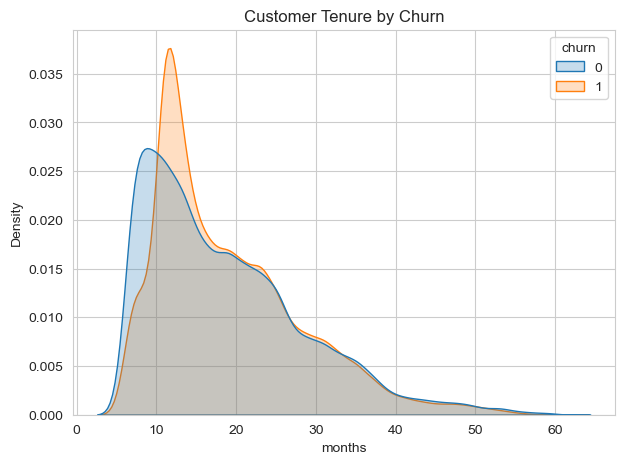

In [25]:
plt.figure(figsize=(7,5))

sns.kdeplot(
    data=df,
    x='months',
    hue='churn',
    fill=True
)

plt.title("Customer Tenure by Churn")

plt.show()

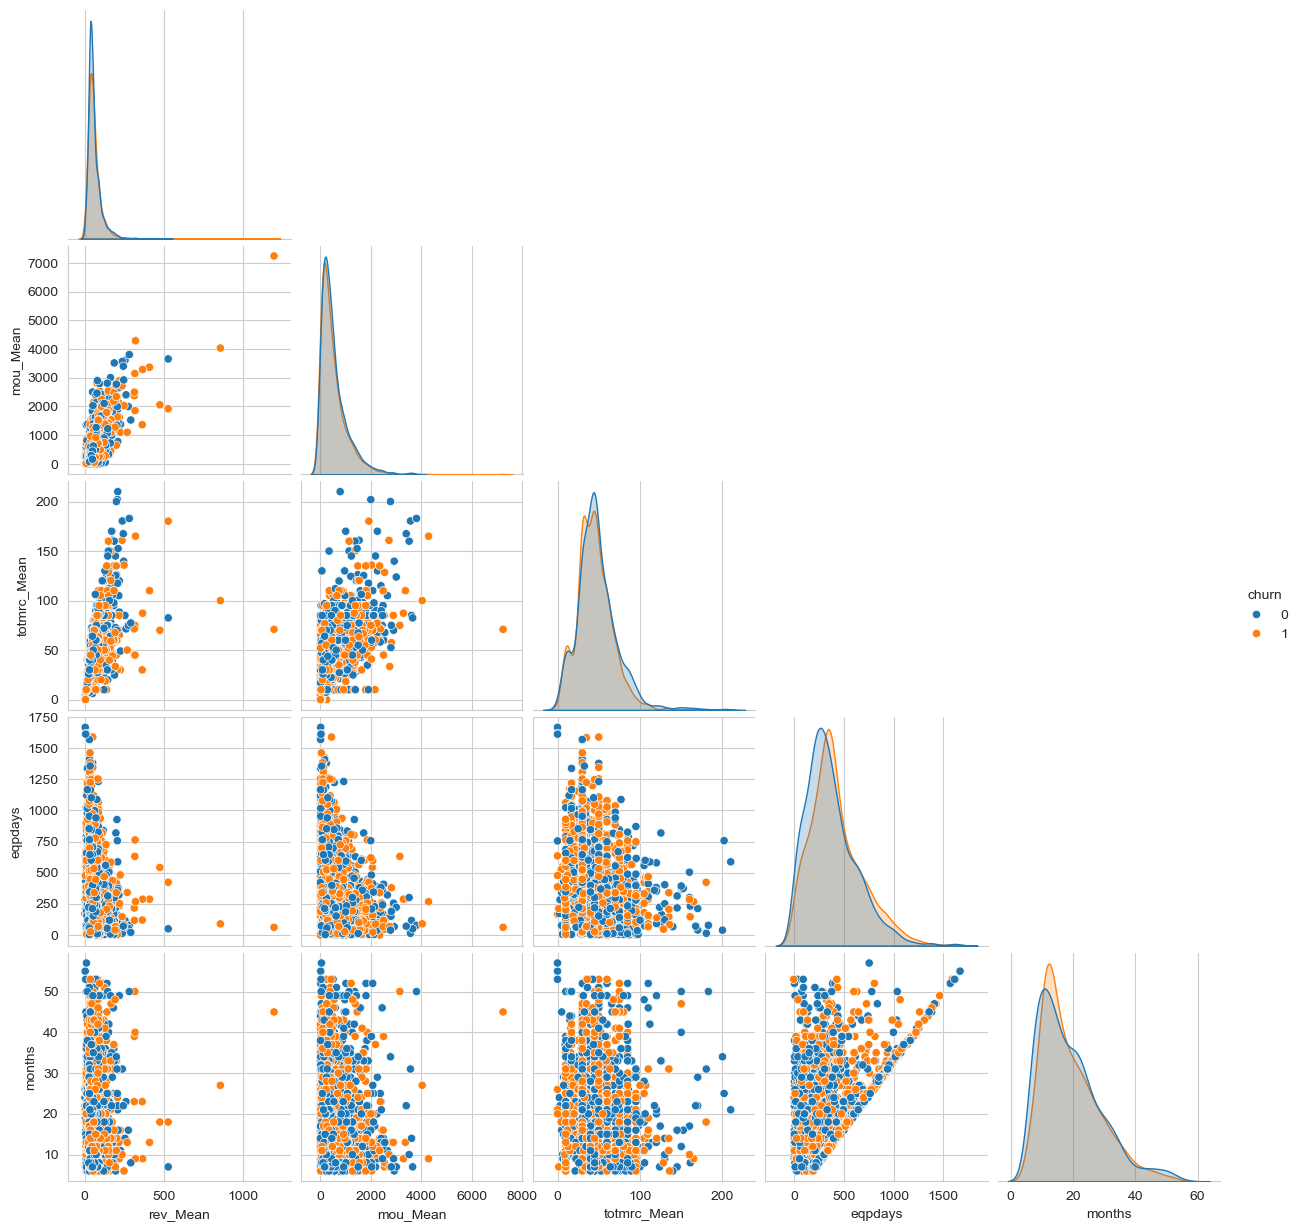

In [27]:
sample_df = df[[
    'rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays',
    'months',
    'churn'
]].sample(3000, random_state=42)

sns.pairplot(
    sample_df,
    hue='churn',
    corner=True
)

plt.show()

In [30]:
# print("="*60)
print("EDA SUMMARY: ")
# print("="*60)

print("\n1. Dataset Shape")
print(df.shape)

print("\n2. Churn Rate")
print(df['churn'].value_counts(normalize=True)*100)

print("\n3. Average Equipment Age by Churn")

print(
    df.groupby('churn')['eqpdays']
    .mean()
)

print("\n4. Average Revenue by Churn")

print(
    df.groupby('churn')['rev_Mean']
    .mean()
)

print("\n5. Average Customer Care Calls by Churn")

print(
    df.groupby('churn')['custcare_Mean']
    .mean()
)

EDA SUMMARY: 

1. Dataset Shape
(100000, 100)

2. Churn Rate
churn
0    50.438
1    49.562
Name: proportion, dtype: float64

3. Average Equipment Age by Churn
churn
0    363.280925
1    421.089524
Name: eqpdays, dtype: float64

4. Average Revenue by Churn
churn
0    59.218692
1    58.211074
Name: rev_Mean, dtype: float64

5. Average Customer Care Calls by Churn
churn
0    1.982599
1    1.595688
Name: custcare_Mean, dtype: float64
